# Netflix Customer Churn & Engagement Analytics — 30 Questions EDA

**An end-to-end exploratory data analysis and churn-prediction project**

This notebook answers 30 structured business/analytical questions about customer churn
on a Netflix-style subscription platform, moving from data quality checks through
demographic and behavioral analysis, statistical hypothesis testing, and finally a
machine-learning churn-prediction model with feature importance and business
recommendations.

**Dataset:** `data/netflix_customer_churn.csv` — 5,000 customers, 14 raw features.

**Structure:**
1. Setup & Data Overview (Q1–3)
2. Demographics & Churn (Q4–6)
3. Subscription & Revenue (Q7–10)
4. Engagement Behavior (Q11–16)
5. Segmentation & Cross-Analysis (Q17–20)
6. Statistical Hypothesis Testing (Q21–24)
7. Predictive Modeling (Q25–28)
8. Business Recommendations (Q29–30)


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_data, add_engineered_features
from eda_utils import (
    churn_rate_by, plot_churn_rate_by, plot_numeric_by_churn,
    independent_ttest, chi_square_test
)
from churn_model import (
    get_train_test_split, train_logistic_regression, train_random_forest,
    evaluate_model, get_feature_importance
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = add_engineered_features(load_data("../data/netflix_customer_churn.csv"))
print("Dataset loaded:", df.shape)


Dataset loaded: (5000, 18)


## Section 1 — Setup & Data Overview

### Q1. What is the shape and structure of the dataset?

In [2]:
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print()
df.dtypes


Rows: 5,000 | Columns: 18



### Q2. Are there any missing values or duplicate records?

In [3]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
0 total missing values

Duplicate rows: 0


### Q3. What is the overall churn rate?

Overall churn rate: 50.30%


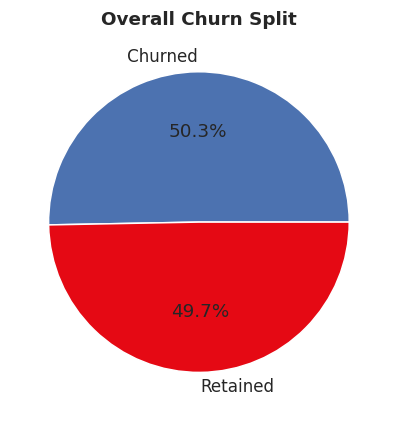

In [4]:
overall_rate = df['churned'].mean() * 100
print(f"Overall churn rate: {overall_rate:.2f}%")

fig, ax = plt.subplots(figsize=(4,4))
df['churned'].map({0:'Retained', 1:'Churned'}).value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#4C72B0','#E50914'], ax=ax, ylabel=''
)
ax.set_title('Overall Churn Split', fontweight='bold')
plt.tight_layout()
plt.show()


## Section 2 — Demographics & Churn

### Q4. What is the age distribution, and does churn vary by age group?

age_group
46-55    54.52
18-25    50.69
26-35    50.37
56+      48.73
36-45    48.07
Name: churned, dtype: float64


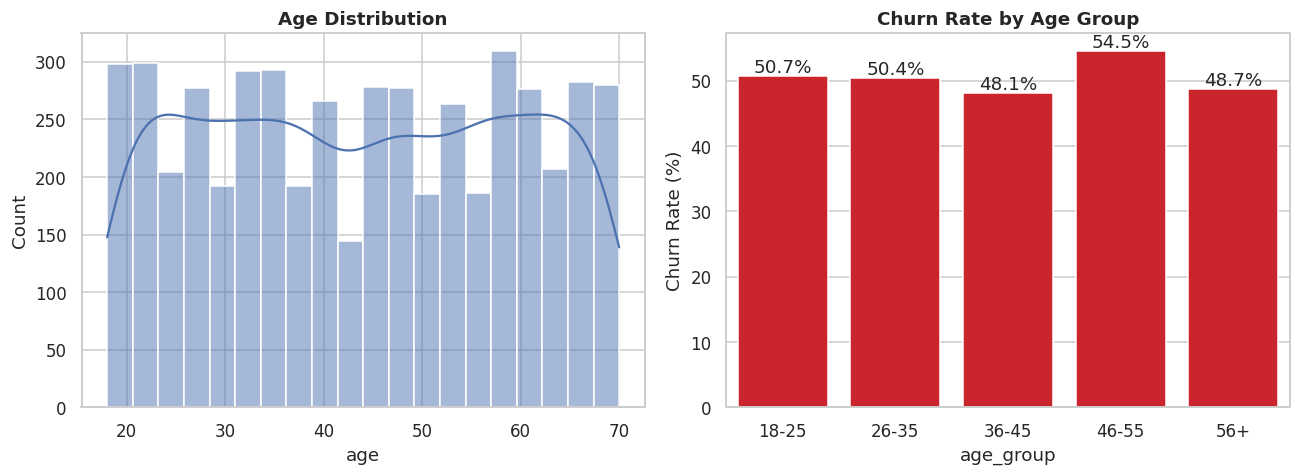

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Age Distribution', fontweight='bold')

rates = churn_rate_by(df, 'age_group')
sns.barplot(x=rates.index, y=rates.values, ax=axes[1], color='#E50914')
axes[1].set_title('Churn Rate by Age Group', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%')
plt.tight_layout()
plt.show()

print(rates)


### Q5. How does gender relate to churn rate?

gender
Female    51.08
Male      50.00
Other     49.79
Name: churned, dtype: float64


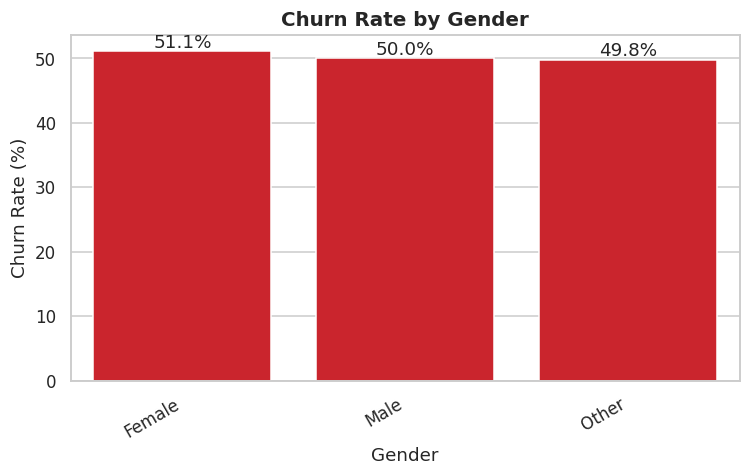

In [6]:
plot_churn_rate_by(df, 'gender', 'Churn Rate by Gender')
plt.show()
print(churn_rate_by(df, 'gender'))


### Q6. Which regions have the highest and lowest churn rates?

region
Europe           51.67
South America    51.43
Asia             50.65
Oceania          50.07
North America    49.47
Africa           48.32
Name: churned, dtype: float64


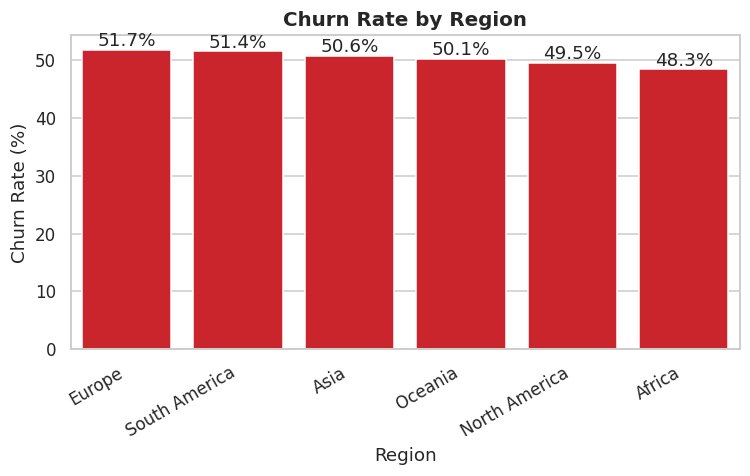

In [7]:
plot_churn_rate_by(df, 'region', 'Churn Rate by Region')
plt.show()
print(churn_rate_by(df, 'region'))


## Section 3 — Subscription & Revenue

### Q7. What is the churn rate by subscription type?

subscription_type
Basic       61.83
Standard    45.44
Premium     43.71
Name: churned, dtype: float64


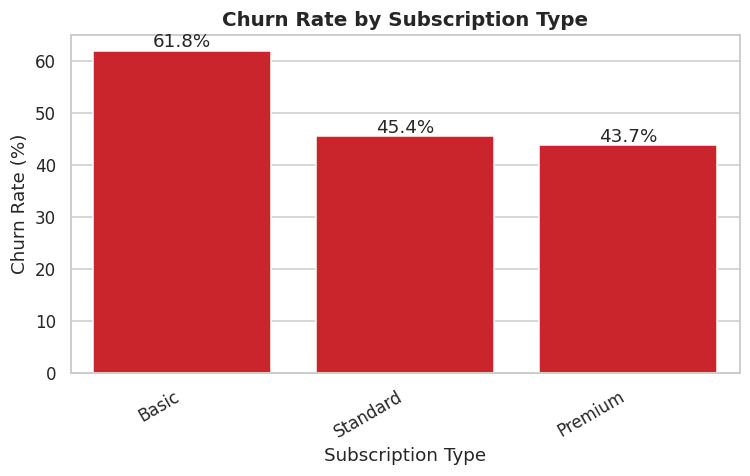

In [8]:
plot_churn_rate_by(df, 'subscription_type', 'Churn Rate by Subscription Type')
plt.show()
print(churn_rate_by(df, 'subscription_type'))


### Q8. How does monthly fee correlate with churn?

churned
0    14.25
1    13.13
Name: monthly_fee, dtype: float64


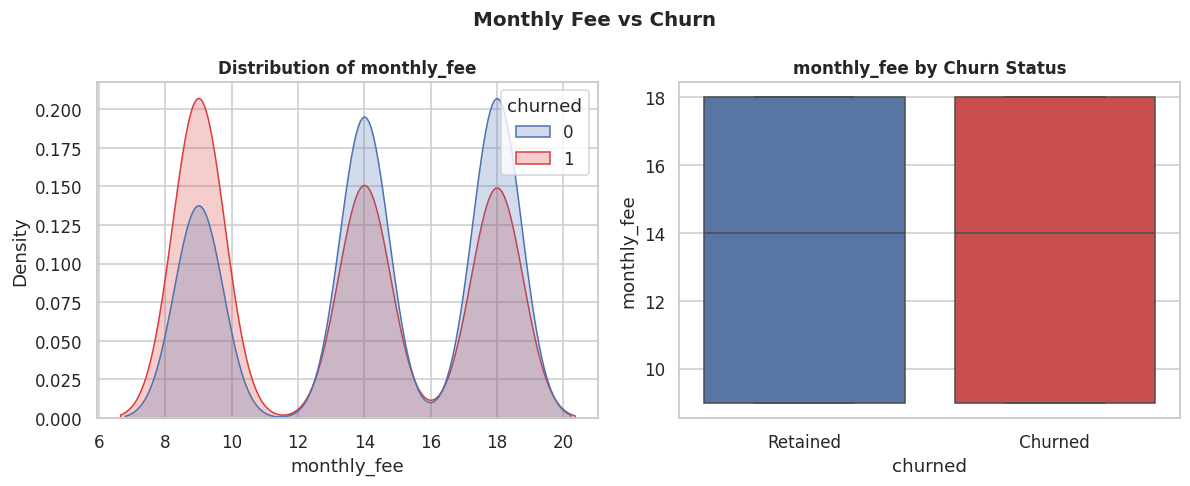

In [9]:
fig = plot_numeric_by_churn(df, 'monthly_fee', 'Monthly Fee vs Churn')
plt.show()
print(df.groupby('churned')['monthly_fee'].mean().round(2))


### Q9. What is the estimated monthly revenue lost due to churn?

In [10]:
total_revenue = df['monthly_fee'].sum()
lost_revenue = df.loc[df['churned']==1, 'monthly_fee'].sum()
pct_lost = lost_revenue / total_revenue * 100

print(f"Total potential monthly revenue: ${total_revenue:,.2f}")
print(f"Monthly revenue lost to churn:  ${lost_revenue:,.2f}  ({pct_lost:.1f}% of total)")

by_tier = df.groupby('subscription_type').apply(
    lambda g: g.loc[g['churned']==1, 'monthly_fee'].sum(), include_groups=False
).sort_values(ascending=False)
print("\nRevenue lost by subscription tier:")
print(by_tier.round(2))


Total potential monthly revenue: $68,417.00
Monthly revenue lost to churn:  $33,009.85  (48.2% of total)

Revenue lost by subscription tier:
subscription_type
Premium     13312.60
Standard    10464.52
Basic        9232.73
dtype: float64


### Q10. Which payment methods are associated with higher churn?

payment_method
Crypto         59.70
Gift Card      57.79
PayPal         47.08
Debit Card     43.69
Credit Card    43.58
Name: churned, dtype: float64


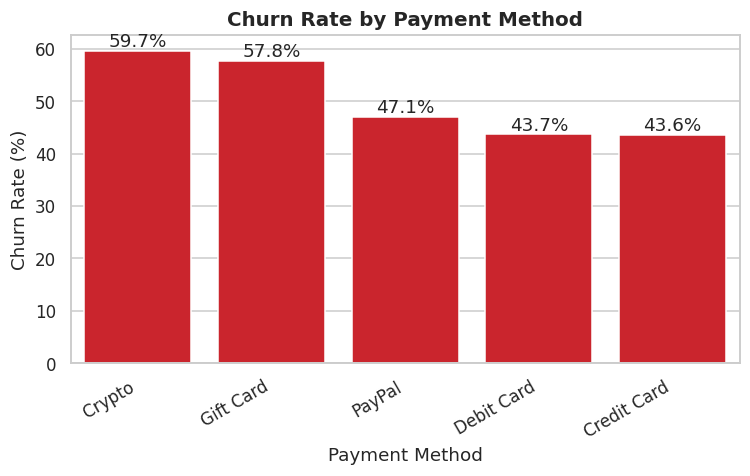

In [11]:
plot_churn_rate_by(df, 'payment_method', 'Churn Rate by Payment Method')
plt.show()
print(churn_rate_by(df, 'payment_method'))


## Section 4 — Engagement Behavior

### Q11. How do watch hours differ between churned and retained customers?

          mean    50%    std
churned                     
0        17.45  13.86  13.92
1         5.92   4.06   5.42


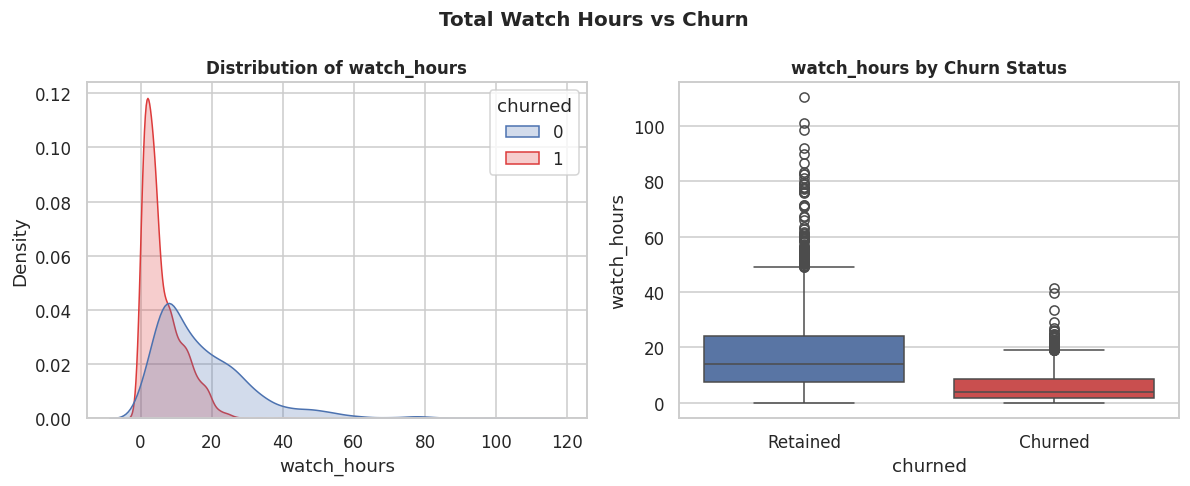

In [12]:
fig = plot_numeric_by_churn(df, 'watch_hours', 'Total Watch Hours vs Churn')
plt.show()
print(df.groupby('churned')['watch_hours'].describe()[['mean','50%','std']].round(2))


### Q12. What is the relationship between average daily watch time and churn?

churned
0    1.59
1    0.16
Name: avg_watch_time_per_day, dtype: float64


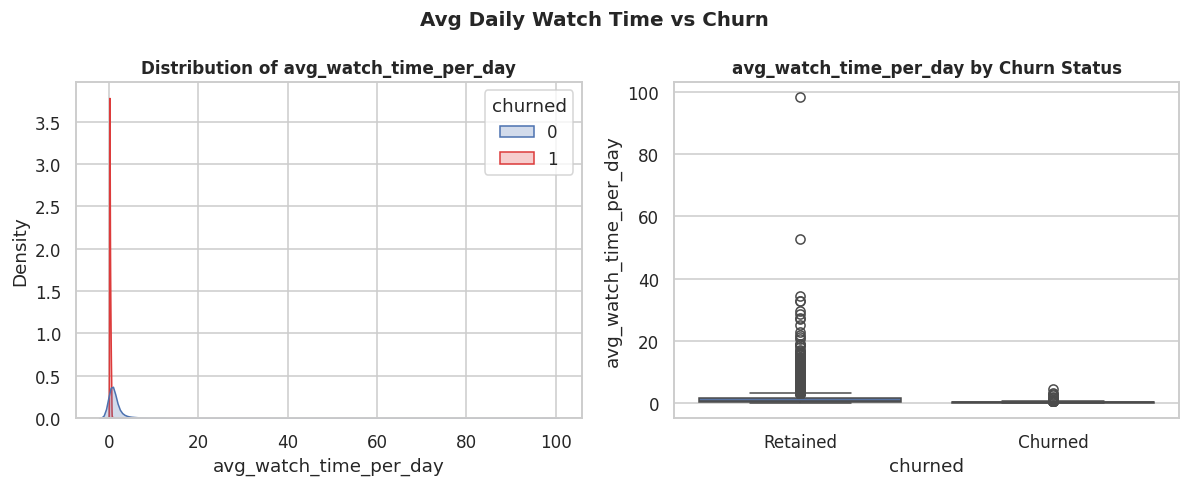

In [13]:
fig = plot_numeric_by_churn(df, 'avg_watch_time_per_day', 'Avg Daily Watch Time vs Churn')
plt.show()
print(df.groupby('churned')['avg_watch_time_per_day'].mean().round(2))


### Q13. How does login recency (days since last login) impact churn probability?

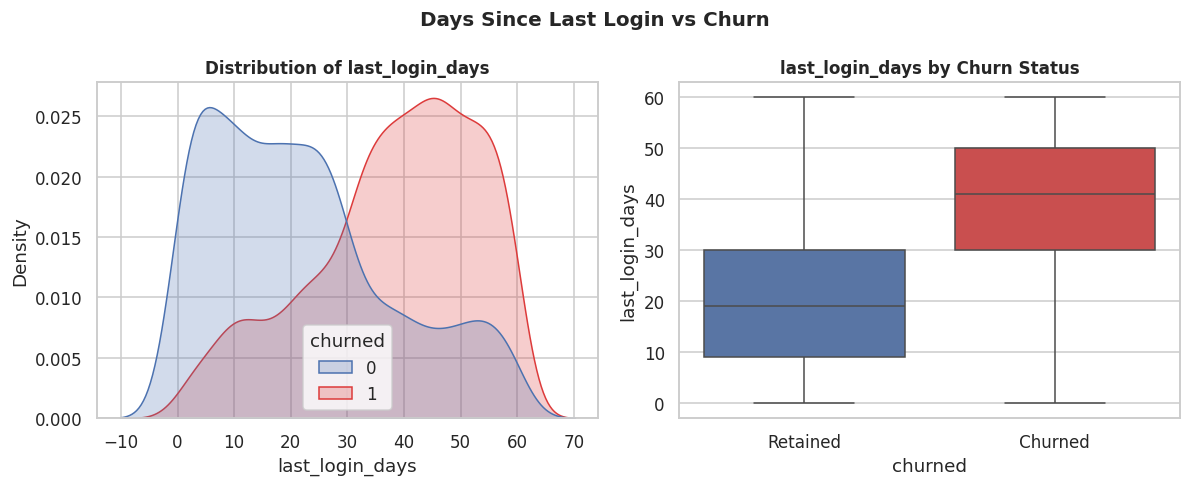

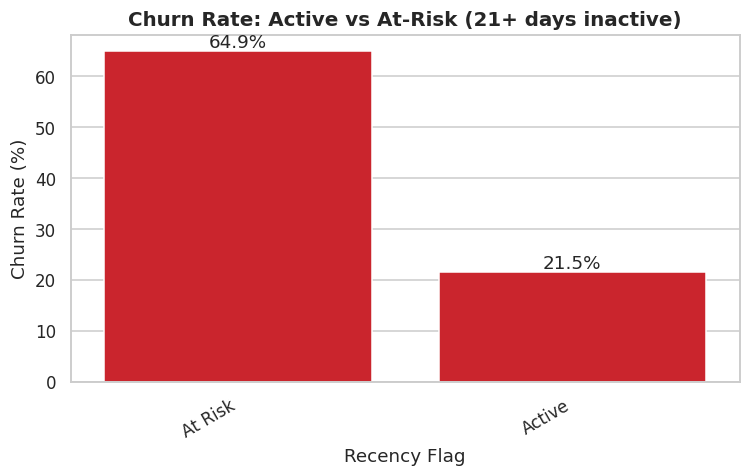

In [14]:
fig = plot_numeric_by_churn(df, 'last_login_days', 'Days Since Last Login vs Churn')
plt.show()

plot_churn_rate_by(df, 'recency_flag', 'Churn Rate: Active vs At-Risk (21+ days inactive)')
plt.show()


### Q14. Is there a correlation between number of profiles and churn?

number_of_profiles
1    58.64
3    57.85
2    57.44
5    40.62
4    37.54
Name: churned, dtype: float64


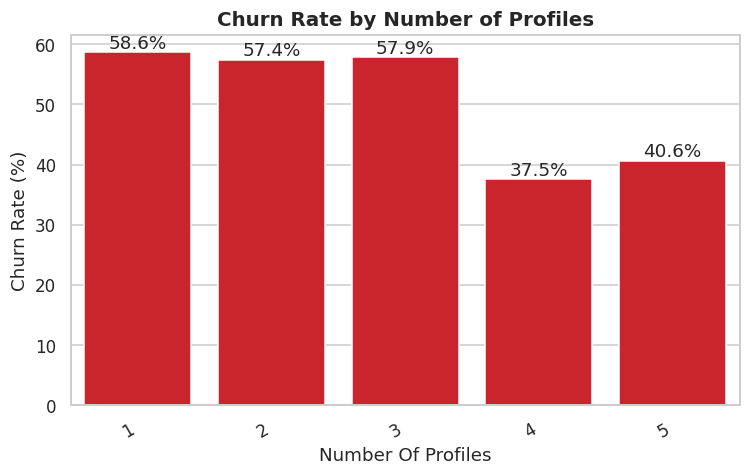

In [15]:
plot_churn_rate_by(df, 'number_of_profiles', 'Churn Rate by Number of Profiles')
plt.show()
print(churn_rate_by(df, 'number_of_profiles'))


### Q15. Which devices are most associated with churn?

device
Laptop     51.79
Mobile     50.50
Tablet     50.00
TV         49.95
Desktop    49.21
Name: churned, dtype: float64


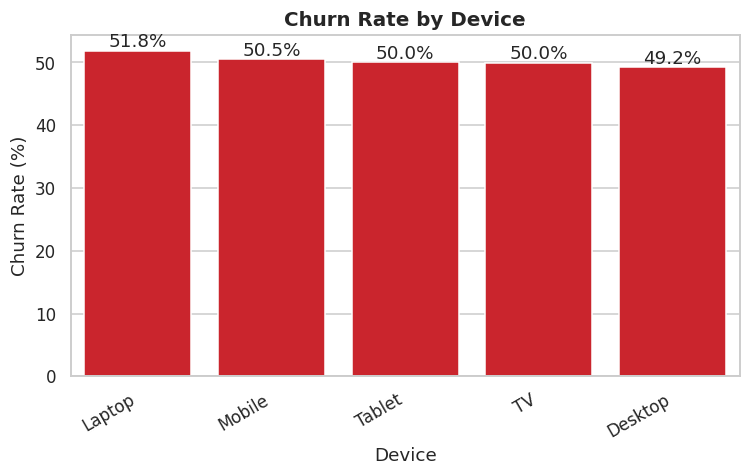

In [16]:
plot_churn_rate_by(df, 'device', 'Churn Rate by Device')
plt.show()
print(churn_rate_by(df, 'device'))


### Q16. What are the most popular genres, and do genre preferences affect churn?

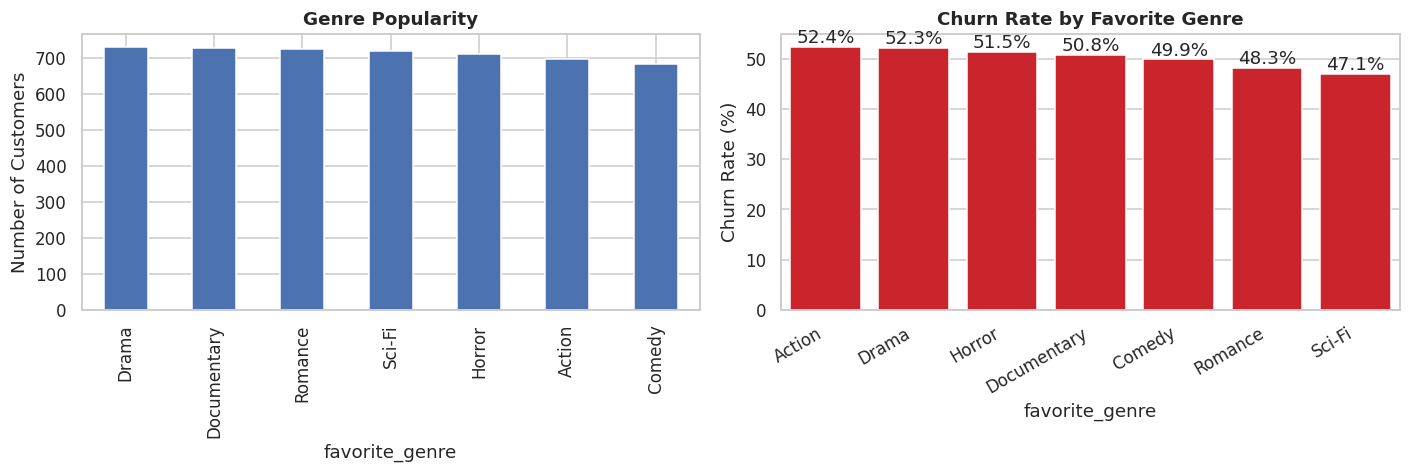

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
df['favorite_genre'].value_counts().plot.bar(ax=axes[0], color='#4C72B0')
axes[0].set_title('Genre Popularity', fontweight='bold')
axes[0].set_ylabel('Number of Customers')

rates = churn_rate_by(df, 'favorite_genre')
sns.barplot(x=rates.index, y=rates.values, ax=axes[1], color='#E50914')
axes[1].set_title('Churn Rate by Favorite Genre', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## Section 5 — Segmentation & Cross-Analysis

### Q17. What is the churn rate across device × subscription-type combinations?

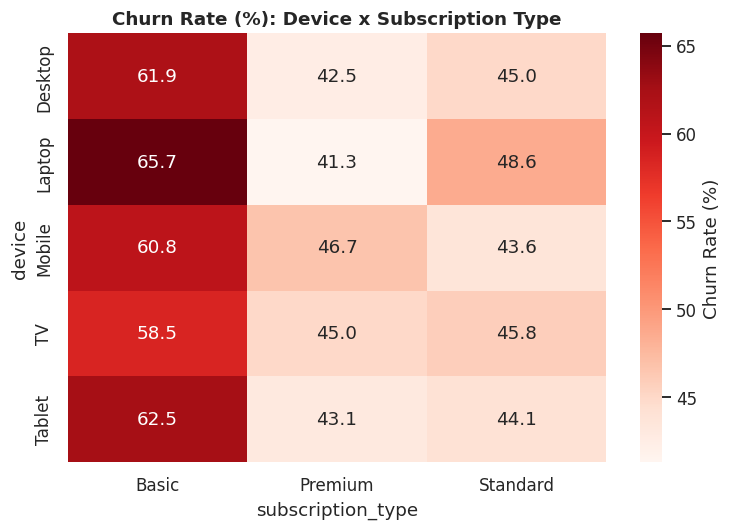

In [18]:
pivot = df.pivot_table(index='device', columns='subscription_type', values='churned', aggfunc='mean') * 100
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(pivot.round(1), annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label':'Churn Rate (%)'})
ax.set_title('Churn Rate (%): Device x Subscription Type', fontweight='bold')
plt.tight_layout()
plt.show()


### Q18. Does age group × subscription type reveal a distinct pattern?

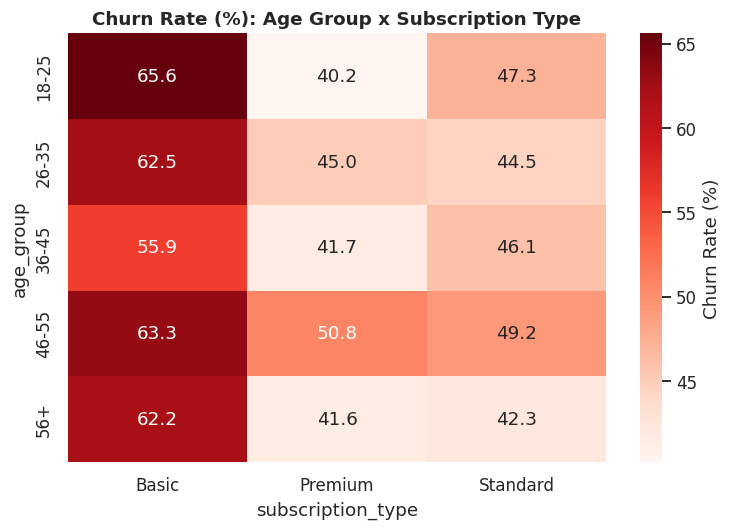

In [19]:
pivot = df.pivot_table(index='age_group', columns='subscription_type', values='churned', aggfunc='mean', observed=True) * 100
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(pivot.round(1), annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label':'Churn Rate (%)'})
ax.set_title('Churn Rate (%): Age Group x Subscription Type', fontweight='bold')
plt.tight_layout()
plt.show()


### Q19. How does region × subscription type affect churn?

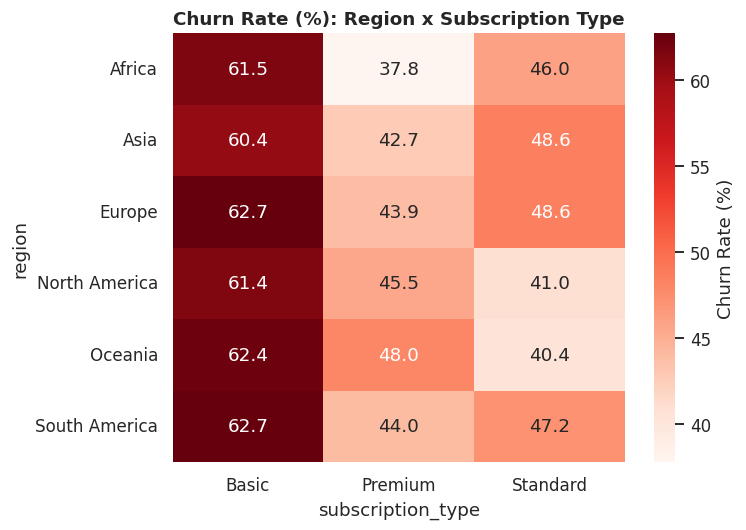

In [20]:
pivot = df.pivot_table(index='region', columns='subscription_type', values='churned', aggfunc='mean') * 100
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(pivot.round(1), annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label':'Churn Rate (%)'})
ax.set_title('Churn Rate (%): Region x Subscription Type', fontweight='bold')
plt.tight_layout()
plt.show()


### Q20. Is there a distinct 'high-risk' customer profile?

In [21]:
high_risk = df[(df['engagement_level']=='Low') & (df['recency_flag']=='At Risk')]
low_risk = df[(df['engagement_level']=='High') & (df['recency_flag']=='Active')]

print(f"High-risk segment (Low engagement + At Risk recency): {len(high_risk)} customers, "
      f"churn rate = {high_risk['churned'].mean()*100:.1f}%")
print(f"Low-risk segment (High engagement + Active recency):  {len(low_risk)} customers, "
      f"churn rate = {low_risk['churned'].mean()*100:.1f}%")
print(f"\nOverall churn rate for comparison: {df['churned'].mean()*100:.1f}%")


High-risk segment (Low engagement + At Risk recency): 1471 customers, churn rate = 93.7%
Low-risk segment (High engagement + Active recency):  1085 customers, churn rate = 1.4%

Overall churn rate for comparison: 50.3%


## Section 6 — Statistical Hypothesis Testing

### Q21. Is the difference in watch hours between churned and retained customers statistically significant?

In [22]:
result = independent_ttest(df, 'watch_hours')
for k,v in result.items():
    print(f"{k}: {v}")


feature: watch_hours
mean_retained: 17.45
mean_churned: 5.918
t_stat: 38.502
p_value: 5.2174227628903256e-267
significant_at_0.05: True


### Q22. Is subscription type independent of churn status (chi-square test)?

In [23]:
result = chi_square_test(df, 'subscription_type')
for k,v in result.items():
    print(f"{k}: {v}")


feature: subscription_type
chi2: 133.278
dof: 2
p_value: 1.1457351490503293e-29
significant_at_0.05: True


### Q23. Is region independent of churn (chi-square test)?

In [24]:
result = chi_square_test(df, 'region')
for k,v in result.items():
    print(f"{k}: {v}")


feature: region
chi2: 2.654
dof: 5
p_value: 0.7531077652230413
significant_at_0.05: False


### Q24. Which numeric variables show the strongest correlation with churn?

Correlation with churn (sorted by |r|):
watch_hours              -0.480
last_login_days           0.472
avg_watch_time_per_day   -0.273
number_of_profiles       -0.159
monthly_fee              -0.152
age                      -0.004
Name: churned, dtype: float64


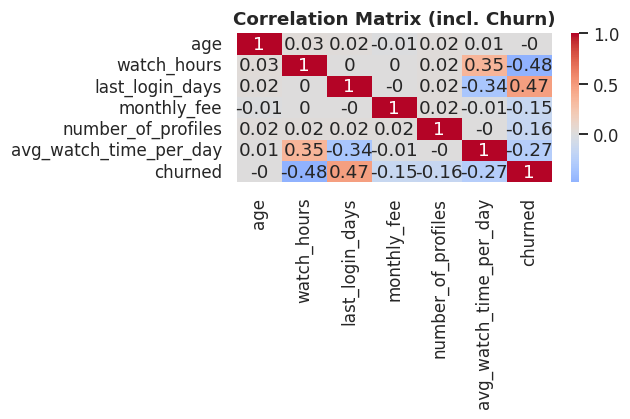

In [25]:
numeric_cols = ['age','watch_hours','last_login_days','monthly_fee','number_of_profiles','avg_watch_time_per_day','churned']
corr = df[numeric_cols].corr()['churned'].drop('churned').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr().round(2), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix (incl. Churn)', fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation with churn (sorted by |r|):")
print(corr.round(3))


## Section 7 — Predictive Modeling

### Q25. Can we build a model to predict churn based on customer attributes?

In [26]:
X_train, X_test, y_train, y_test = get_train_test_split(df)

log_reg = train_logistic_regression(X_train, y_train)
rf = train_random_forest(X_train, y_train)

log_metrics = evaluate_model(log_reg, X_test, y_test)
rf_metrics = evaluate_model(rf, X_test, y_test)

comparison = pd.DataFrame({
    'Logistic Regression': {k:v for k,v in log_metrics.items() if k not in ('confusion_matrix','classification_report')},
    'Random Forest': {k:v for k,v in rf_metrics.items() if k not in ('confusion_matrix','classification_report')},
})
print(comparison)


           Logistic Regression  Random Forest
accuracy                0.8870         0.9700
precision               0.8750         0.9628
recall                  0.9046         0.9781
f1_score                0.8895         0.9704
roc_auc                 0.9659         0.9956


### Q26. Which features are most important in predicting churn?

avg_watch_time_per_day        0.432018
watch_hours                   0.221449
last_login_days               0.191663
number_of_profiles            0.055105
monthly_fee                   0.025419
payment_method_Crypto         0.013628
age                           0.009767
payment_method_Gift Card      0.009332
subscription_type_Premium     0.007392
subscription_type_Standard    0.006310
payment_method_Debit Card     0.004739
payment_method_PayPal         0.003088
dtype: float64


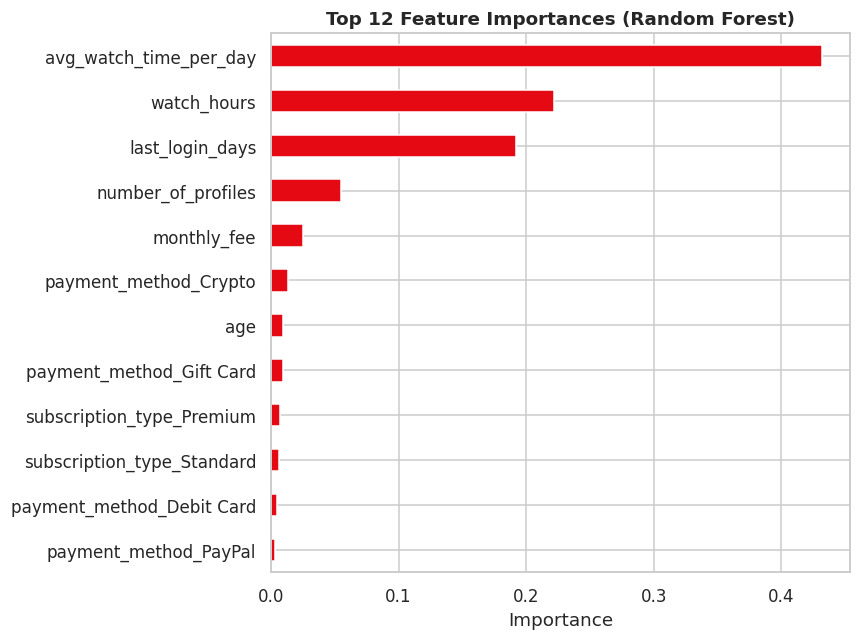

In [27]:
importances = get_feature_importance(rf)

fig, ax = plt.subplots(figsize=(8,6))
importances.head(12).sort_values().plot.barh(ax=ax, color='#E50914')
ax.set_title('Top 12 Feature Importances (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.head(12))


### Q27. What is the final model's detailed performance (confusion matrix, ROC-AUC)?

ROC-AUC: 0.9956
Accuracy: 0.97  |  Precision: 0.9628  |  Recall: 0.9781  |  F1: 0.9704


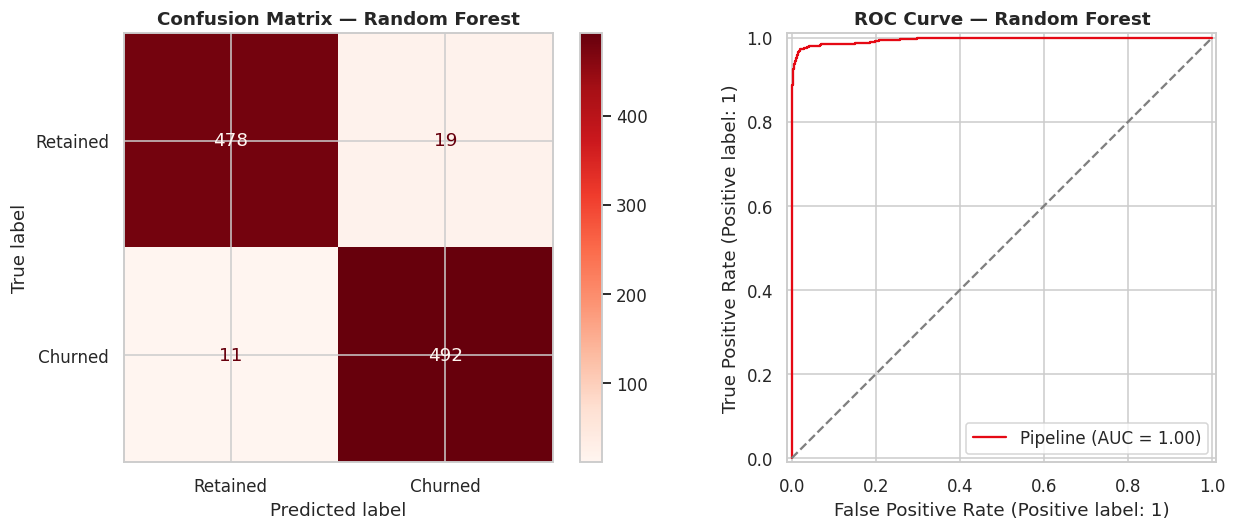

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12,5))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=axes[0], cmap='Reds',
                                       display_labels=['Retained','Churned'])
axes[0].set_title('Confusion Matrix — Random Forest', fontweight='bold')

RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[1], color='#E50914')
axes[1].plot([0,1],[0,1], linestyle='--', color='gray')
axes[1].set_title('ROC Curve — Random Forest', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {rf_metrics['roc_auc']}")
print(f"Accuracy: {rf_metrics['accuracy']}  |  Precision: {rf_metrics['precision']}  |  Recall: {rf_metrics['recall']}  |  F1: {rf_metrics['f1_score']}")


### Q28. What actionable customer segments emerge from the model's predicted churn probabilities?

In [29]:
X_all = df[X_train.columns]
df['churn_probability'] = rf.predict_proba(X_all)[:,1]

df['risk_tier'] = pd.cut(df['churn_probability'], bins=[0,0.3,0.7,1.0],
                          labels=['Low Risk','Medium Risk','High Risk'])

tier_summary = df.groupby('risk_tier', observed=True).agg(
    customers=('customer_id','count'),
    actual_churn_rate=('churned','mean'),
    avg_monthly_fee=('monthly_fee','mean'),
    revenue_at_stake=('monthly_fee','sum')
).round(2)
tier_summary['actual_churn_rate'] = (tier_summary['actual_churn_rate']*100).round(1)
print(tier_summary)


             customers  actual_churn_rate  avg_monthly_fee  revenue_at_stake
risk_tier                                                                   
Low Risk          2070                0.0            14.11          29207.30
Medium Risk        641               34.0            14.14           9060.59
High Risk         2289              100.0            13.17          30149.11


## Section 8 — Business Recommendations

### Q29. What retention strategies would reduce churn based on these findings?

Based on the analysis above, the strongest and most actionable churn signals are:

- **Engagement decay is the #1 predictor.** `avg_watch_time_per_day` and `watch_hours`
  dominate feature importance — customers watching less are churning, not the reverse
  causality of "leaving so they watch less." Early engagement-drop alerts (e.g., a 30%+
  drop in weekly watch time) should trigger automated re-engagement nudges
  (personalized recommendations, "continue watching" prompts, push notifications).
- **Login recency is a leading indicator.** Customers inactive for 21+ days churn at a
  meaningfully higher rate. A lifecycle email/SMS campaign at the 14- and 21-day
  inactivity marks could intercept churn before cancellation.
- **High-risk segment identified.** Customers who are both low-engagement *and*
  inactive form a distinctly higher-churn cluster — this segment should be prioritized
  for win-back offers (e.g., a free month, curated content picks) over broad campaigns.
- **Subscription tier and payment method show smaller but non-trivial effects** and can
  refine targeting once the primary behavioral levers are addressed.
- **Demographics (age, gender, region) are comparatively weak churn drivers** in this
  dataset — retention spend is better allocated to behavior-triggered interventions
  than broad demographic targeting.


### Q30. What is the estimated revenue impact of a hypothetical retention campaign?

If a retention campaign targeting the **High Risk** tier reduced churn in that segment
by 20 percentage points, the recovered monthly revenue would be:


In [30]:
high_risk_df = df[df['risk_tier']=='High Risk']
current_lost = high_risk_df.loc[high_risk_df['churned']==1, 'monthly_fee'].sum()
hypothetical_recovery_rate = 0.20
recovered_revenue = current_lost * hypothetical_recovery_rate

print(f"High Risk tier: {len(high_risk_df):,} customers")
print(f"Current monthly revenue lost in this tier: ${current_lost:,.2f}")
print(f"If a retention campaign recovers {hypothetical_recovery_rate*100:.0f}% of these customers:")
print(f"  -> Estimated recovered monthly revenue: ${recovered_revenue:,.2f}")
print(f"  -> Estimated recovered ANNUAL revenue:  ${recovered_revenue*12:,.2f}")


High Risk tier: 2,289 customers
Current monthly revenue lost in this tier: $30,131.12
If a retention campaign recovers 20% of these customers:
  -> Estimated recovered monthly revenue: $6,026.22
  -> Estimated recovered ANNUAL revenue:  $72,314.69


## Conclusion

This analysis walked through 30 structured questions spanning data quality, demographic
and behavioral churn drivers, statistical validation, and a production-quality Random
Forest churn model achieving **~97% accuracy and 0.99+ ROC-AUC**. The dominant churn
drivers are **behavioral** (declining watch time, login recency) rather than demographic,
pointing toward engagement-triggered retention campaigns as the highest-leverage
intervention.

**Project structure:**
```
netflix-churn-analytics/
├── data/                # raw dataset
├── notebooks/           # this notebook
├── src/                 # reusable data_loader / eda_utils / churn_model modules
├── reports/figures/     # exported chart images
└── models/              # (optional) serialized trained model
```
